# Unit 1: EEG基础与MNE数据结构

## 理论知识

### 1.1 EEG信号基础

脑电图（Electroencephalography, EEG）是一种非侵入性的神经影像学技术，通过放置在头皮上的电极记录大脑神经元活动产生的电信号。

**关键特性：**
- **频率范围**：0.1-100 Hz（常用分析范围：0.5-40 Hz）
- **振幅范围**：10-100 μV（微伏）
- **采样率**：通常250-2000 Hz

**主要频段：**
| 频段 | 频率范围 | 相关状态 |
|------|----------|----------|
| Delta (δ) | 0.5-4 Hz | 深度睡眠 |
| Theta (θ) | 4-8 Hz | 困倦、冥想 |
| Alpha (α) | 8-13 Hz | 放松、闭眼 |
| Beta (β) | 13-30 Hz | 清醒、专注 |
| Gamma (γ) | 30-100 Hz | 高级认知处理 |

### 1.2 10-20电极系统

国际10-20系统是EEG电极放置的标准方法，根据头颅的解剖标志点（鼻根Nasion、枕外隆凸Inion）按比例分配电极位置。

**电极命名规则：**
- 字母表示脑区：Fp（额极）、F（额）、C（中央）、P（顶）、O（枕）、T（颞）
- 数字表示半球：奇数=左半球，偶数=右半球
- Z表示中线位置

### 1.3 MNE-Python核心数据结构

MNE-Python是处理EEG/MEG数据的主流Python库，其核心数据结构包括：

**Raw对象**：连续原始数据
- 存储未经分割的连续时间序列数据
- 包含通道信息、采样率、事件标记等元数据

**Epochs对象**：分段数据
- 根据事件标记将连续数据切分为固定时间窗口
- 每个epoch对应一次试验（trial）
- 用于ERP和时频分析

**Evoked对象**：平均数据
- 对多个epochs进行时间锁定平均
- 用于ERP分析，增强信噪比

**Info对象**：元数据容器
- 存储通道信息、采样率、电极位置等
- 存在于所有MNE数据结构中

### 1.4 数据导入与可视化

MNE支持多种EEG数据格式的导入：
- EEG `.set` (EEGLAB)
- `.edf` (European Data Format)
- `.bdf` (BioSemi)
- `.vhdr` (BrainVision)
- 以及MNE自带示例数据

## 实践代码

In [1]:
# 导入必要的库
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

# 设置MNE日志级别，减少不必要的输出
mne.set_log_level('WARNING')

print(f"MNE-Python版本: {mne.__version__}")
print(f"NumPy版本: {np.__version__}")

MNE-Python版本: 1.12.1
NumPy版本: 2.4.4


### 1. 加载示例数据

使用MNE内置的示例数据集进行演示

In [2]:
# 修改MNE配置，指向本地数据集目录
data_dir = os.path.abspath("../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

# 加载MNE示例数据
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'

# 读取原始数据
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)

# 查看数据基本信息
print(raw.info)

<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


### 2. 探索数据结构

了解Raw对象的关键属性和方法

In [3]:
# 查看采样率
print(f"采样率: {raw.info['sfreq']} Hz")

# 查看数据持续时间
duration = raw.times[-1]
print(f"数据持续时间: {duration:.2f} 秒 ({duration/60:.2f} 分钟)")

# 查看通道数量
print(f"总通道数: {len(raw.ch_names)}")

# 查看通道类型分布
ch_types = raw.get_channel_types(unique=True)
print(f"通道类型: {ch_types}")

# 获取EEG通道名称
eeg_channels = mne.pick_types(raw.info, eeg=True, exclude=[])
eeg_ch_names = [raw.ch_names[i] for i in eeg_channels]
print(f"\nEEG通道数量: {len(eeg_ch_names)}")
print(f"EEG通道名称: {eeg_ch_names}")

采样率: 150.15374755859375 Hz
数据持续时间: 277.71 秒 (4.63 分钟)
总通道数: 376
通道类型: ['grad', 'mag', 'stim', 'eeg', 'eog']

EEG通道数量: 60
EEG通道名称: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']


### 3. 数据可视化

使用MNE提供的可视化工具探索数据

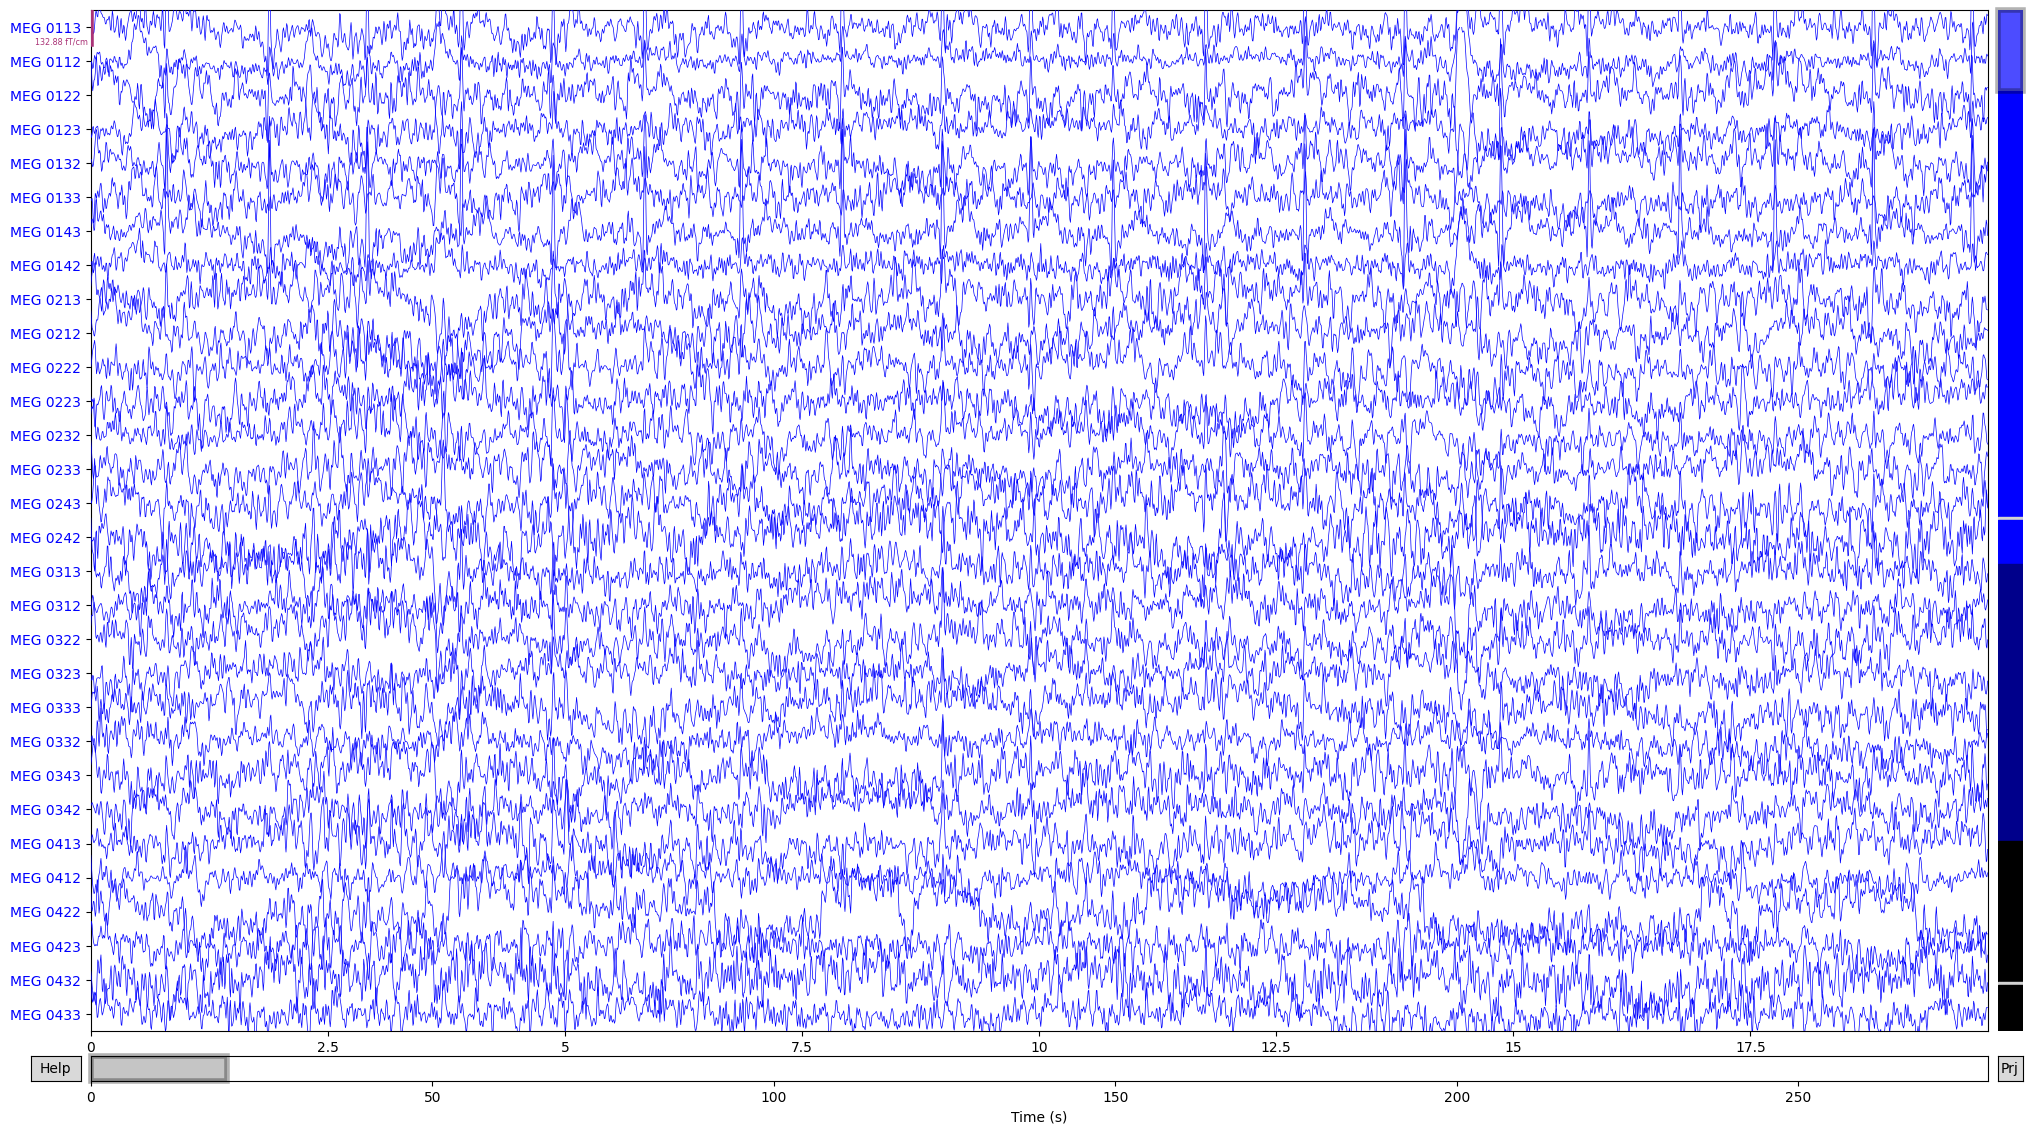

Raw EEG Data Plot


<Figure size 640x480 with 0 Axes>

In [4]:
# 绘制前20秒的EEG数据
# scalings='auto' 自动缩放不同通道类型
raw.plot(duration=20, n_channels=30, scalings='auto', 
         title='Raw EEG Data (First 20 seconds)', 
         show_scrollbars=True, block=False)
plt.tight_layout()
print("Raw EEG Data Plot")

### 4. 电极位置可视化

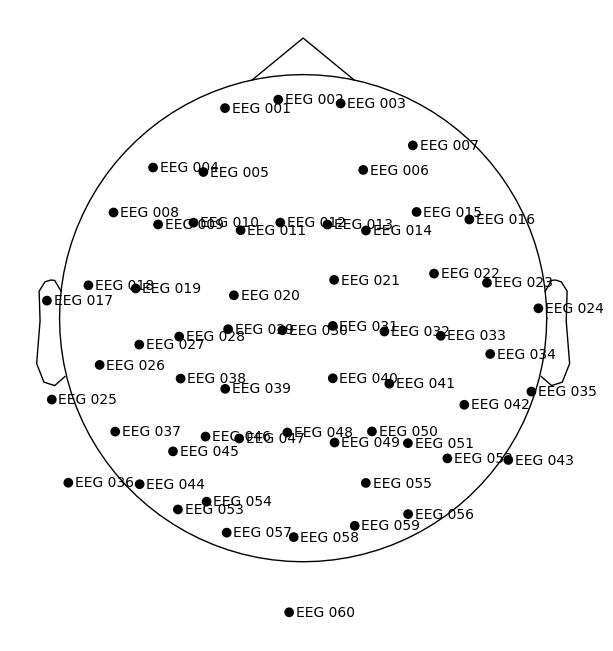

EEG Electrode Positions Plot


In [5]:
# 绘制EEG通道位置
# 仅选择EEG通道进行可视化
montage = raw.get_montage()
if montage is not None:
    montage.plot(kind='topomap', show_names=True)
else:
    print("数据中未包含电极位置信息")
print("EEG Electrode Positions Plot")

### 5. 功率谱密度分析

查看不同频段的功率分布

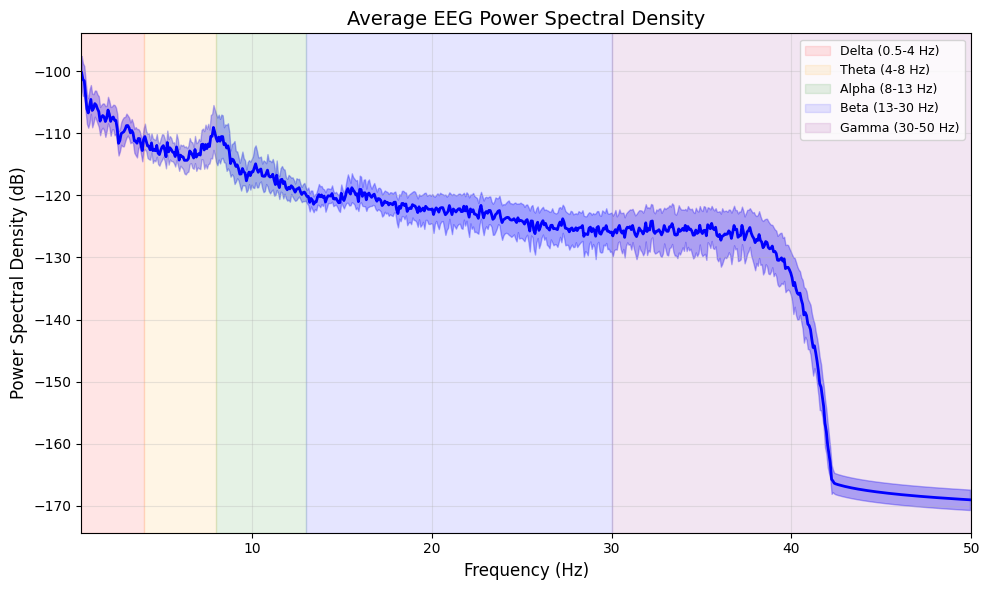

EEG Power Spectral Density Plot


In [ ]:
# 计算并绘制功率谱密度(PSD)
# 使用Welch方法估计PSD
fig, ax = plt.subplots(figsize=(10, 6))

# 仅选择EEG通道
raw_eeg = raw.copy().pick_types(eeg=True)

# 计算PSD (0.5-50 Hz范围)
# 使用Welch方法计算功率谱密度
# method='welch': 采用Welch方法进行PSD估计，通过对信号分段并加窗平均来降低方差
# 计算功率谱密度
spectrum = raw_eeg.compute_psd(
    method='welch',  # 使用Welch方法进行PSD估计
    fmin=0.5,        # 最小频率0.5 Hz
    fmax=50,         # 最大频率50 Hz
    n_fft=2048       # FFT点数2048
)

# 获取PSD数据值，return_freqs=False表示只返回PSD值，不包含频率信息
psds, freqs = spectrum.get_data(return_freqs=True) # psds shape:(59, 675), freqs shape:(675,)

# 转换为dB scale
psds_db = 10 * np.log10(psds) # psds_db shape:(59, 675)

# 绘制平均PSD
# 计算所有通道的平均PSD（沿通道轴求平均）
mean_psd = np.mean(psds_db, axis=0)
# 计算所有通道PSD的标准差（用于绘制置信区间）
std_psd = np.std(psds_db, axis=0)

ax.plot(freqs, mean_psd, linewidth=2, color='blue')
ax.fill_between(freqs, mean_psd - std_psd, mean_psd + std_psd, 
                alpha=0.3, color='blue')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power Spectral Density (dB)', fontsize=12)
ax.set_title('Average EEG Power Spectral Density', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 50)

# 标注主要频段
bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 
         'Beta': (13, 30), 'Gamma': (30, 50)}
colors = ['red', 'orange', 'green', 'blue', 'purple']
for (name, (fmin, fmax)), color in zip(bands.items(), colors):
    ax.axvspan(fmin, fmax, alpha=0.1, color=color, label=f'{name} ({fmin}-{fmax} Hz)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()
print("EEG Power Spectral Density Plot")

### 6. 从Raw数据创建Epochs

根据事件标记将连续数据切分为试验片段

In [7]:
# 查找数据中的事件
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
print(f"检测到的事件数量: {len(events)}")
print(f"\n前10个事件:\n{events[:10]}")

# 查看不同事件类型的数量
event_ids = np.unique(events[:, 2])
print(f"\n事件类型ID: {event_ids}")

# 定义事件ID映射（听觉左=1，听觉右=2，视觉左=3，视觉右=4）
event_dict = {
    'auditory/left': 1, 
    'auditory/right': 2,
    'visual/left': 3, 
    'visual/right': 4
}
print(f"\n事件映射: {event_dict}")

检测到的事件数量: 319

前10个事件:
[[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]
 [7506    0    3]
 [7612    0    1]
 [7709    0    4]
 [7810    0    2]
 [7916    0    3]]

事件类型ID: [ 1  2  3  4  5 32]

事件映射: {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}


In [8]:
# 创建Epochs
# tmin: epoch开始时间(相对事件触发点，负值表示事件前)
# tmax: epoch结束时间
# baseline: 基线校正时间窗口
tmin, tmax = -0.2, 0.5  # 事件前200ms到事件后500ms

epochs = mne.Epochs(raw, events, event_id=event_dict, 
                    tmin=tmin, tmax=tmax,
                    baseline=(None, 0),  # 使用事件前全部时间作为基线
                    preload=True, verbose=False)

print(f"\nEpochs对象信息:")
print(f"- 试验数量: {len(epochs)}")
print(f"- 时间点数: {epochs.times.shape[0]}") # 106
print(f"- 通道数: {epochs.info['nchan']}")
print(f"- 时间窗口: [{tmin}, {tmax}] 秒")


Epochs对象信息:
- 试验数量: 288
- 时间点数: 106
- 通道数: 376
- 时间窗口: [-0.2, 0.5] 秒


### 7. 查看Epochs数据

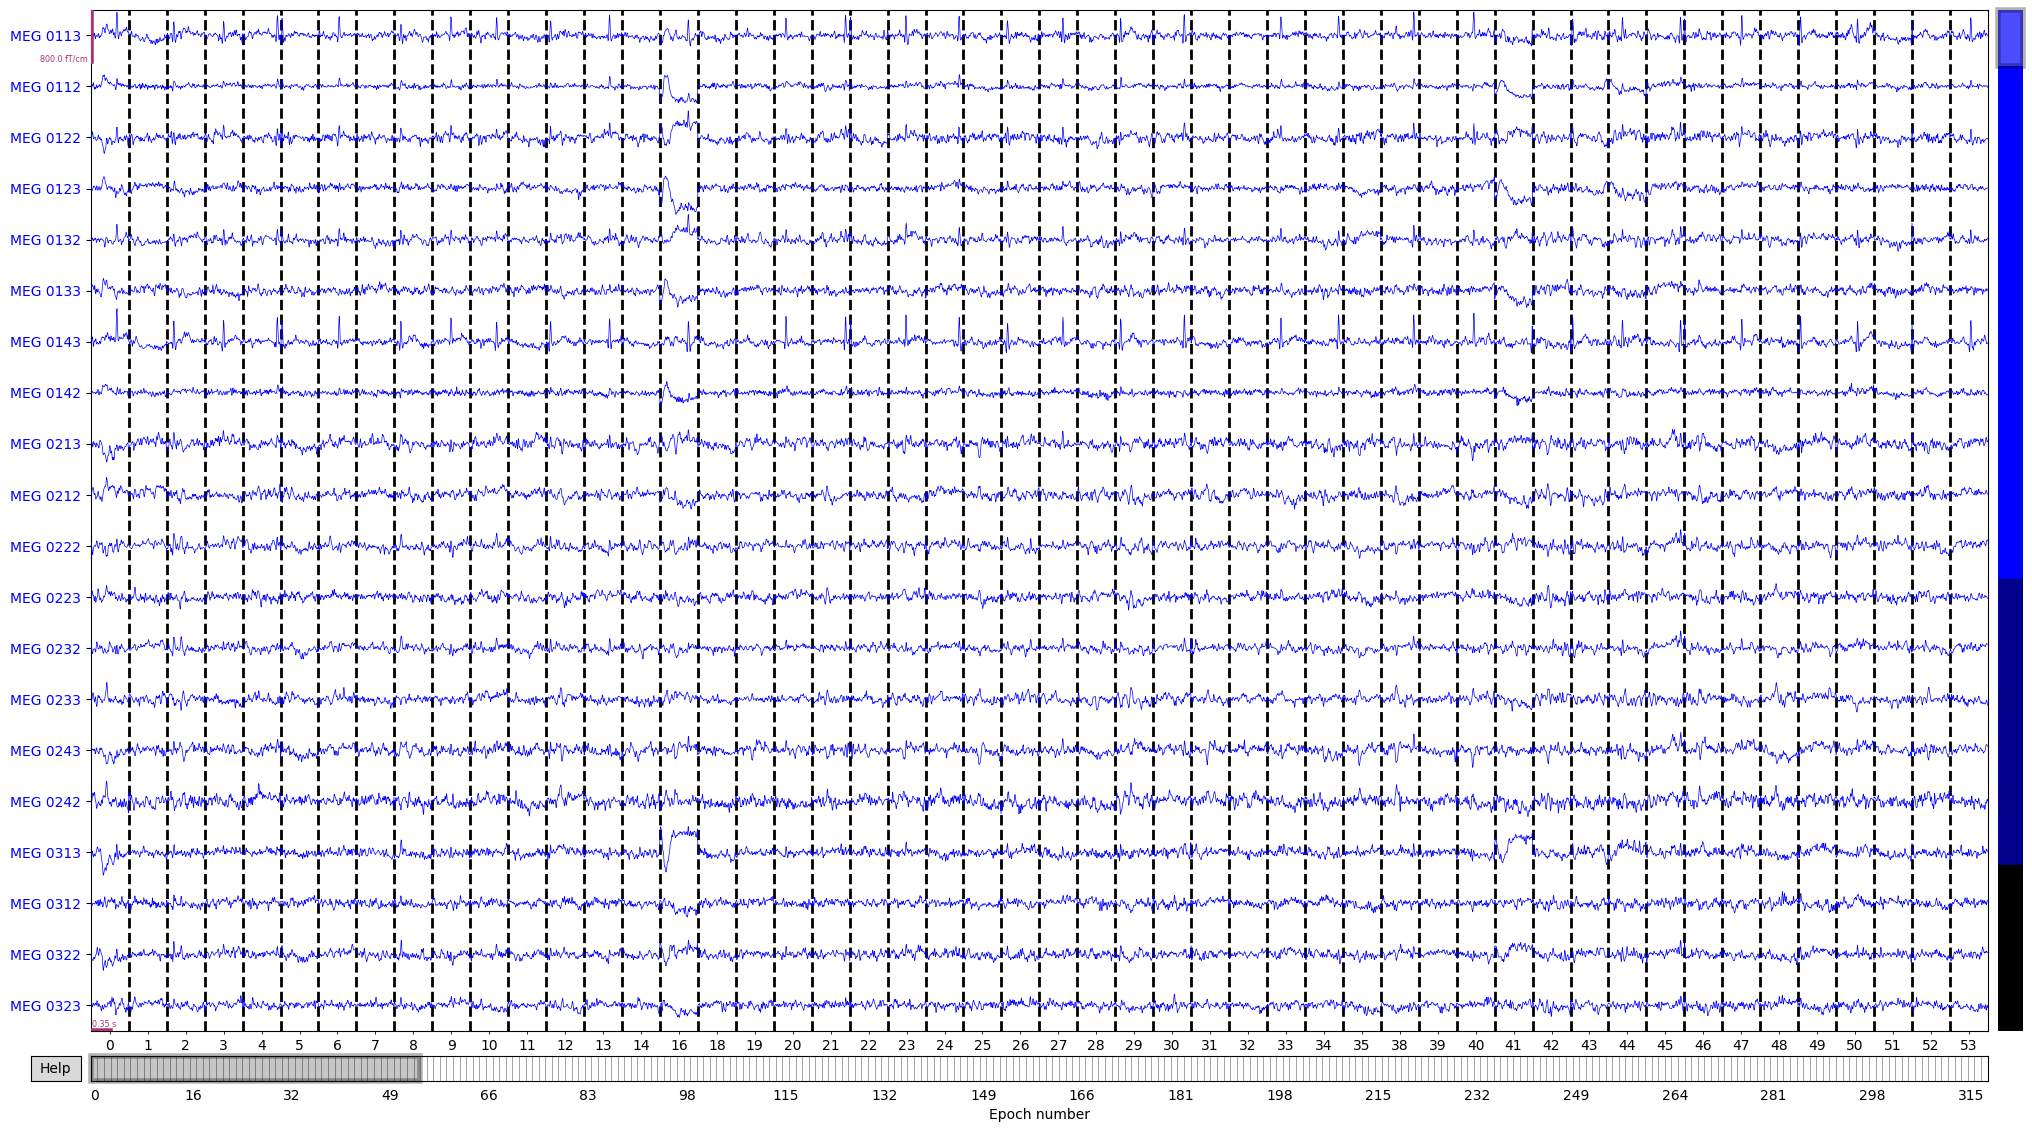

Epochs Overlay Plot


In [9]:
# 可视化epochs数据
# 绘制前50个trials的叠加图
epochs.plot(n_epochs=50, title='EEG Epochs Overlay', block=False)
print("Epochs Overlay Plot")


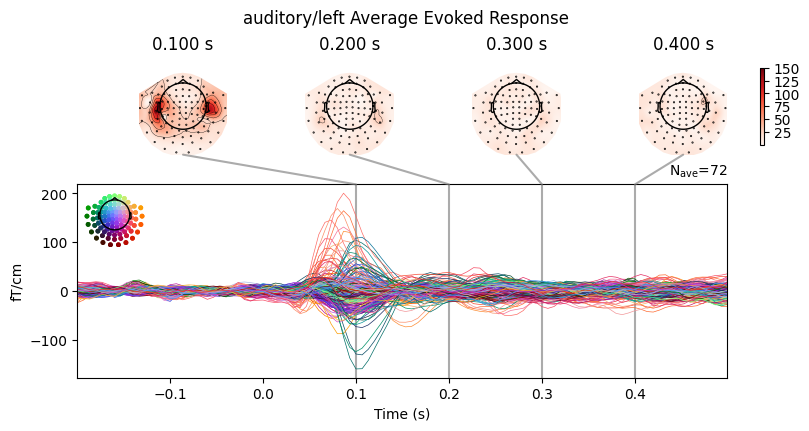

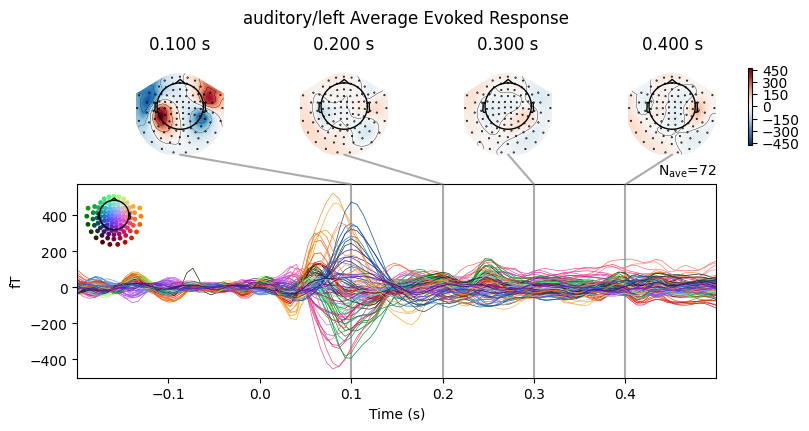

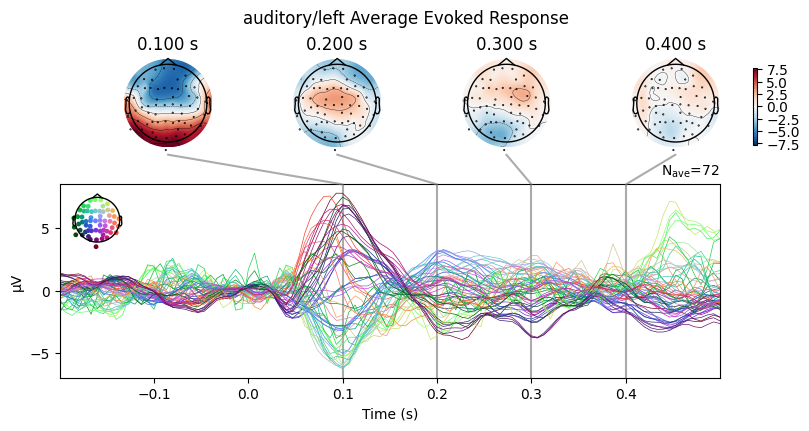

Average Evoked Response Plot


In [10]:
# 绘制特定通道类型的平均epochs
evoked = epochs.average()

# 这里 epochs.average() 是把 所有 4 种条件混在一起 求总平均。实际分析中通常会按条件分开：
evoked_aud_left  = epochs['auditory/left'].average()   # 仅听觉左
evoked_vis_right = epochs['visual/right'].average()    # 仅视觉右


# Gradiometer 图 → 纵轴标为 fT/cm ，显示梯度计通道的场地形
# Magnetometer 图 → 纵轴标为 fT ，显示磁强计通道的场地形
# EEG 图 → 纵轴标为 μV ，显示头皮电位分布
evoked_aud_left.plot_joint(title='auditory/left Average Evoked Response', 
                            times=[0.1, 0.2, 0.3, 0.4])

print("Average Evoked Response Plot")

### 8. 数据导出与保存

In [11]:
# 创建目录
outputs_dir = os.path.abspath("../outputs")
os.makedirs(outputs_dir, exist_ok=True)
# 保存epochs到文件（便于后续分析使用）
epochs_file = os.path.join(outputs_dir, 'sample_epochs-epo.fif')
epochs.save(epochs_file, overwrite=True)
print(f"Epochs已保存到: {epochs_file}")

# 从文件重新加载epochs
epochs_loaded = mne.read_epochs(epochs_file, preload=True)
print(f"\n重新加载的Epochs: {len(epochs_loaded)} trials")

Epochs已保存到: /Users/usst_ziyi/Programs/trae/EEG/ERP-1/outputs/sample_epochs-epo.fif

重新加载的Epochs: 288 trials


## 单元小结

**关键知识点回顾：**
1. **EEG信号特性**：低频（0.1-100 Hz）、低幅（10-100 μV）
2. **MNE数据结构**：Raw（连续数据）、Epochs（分段数据）、Evoked（平均数据）
3. **数据可视化**：时域波形、功率谱密度、电极位置图
4. **事件处理**：从刺激通道检测事件，根据事件创建epochs

**下一步学习：**
- Unit 2将学习EEG预处理的基础操作，包括滤波、重参考、坏道检测和ICA去伪迹

**练习建议：**
1. 尝试修改PSD分析的频率范围，观察不同频段特征
2. 创建仅包含听觉或视觉事件的epochs子集
3. 尝试使用不同的基线校正窗口，观察对数据的影响